In [2]:
import os
from glob import glob as glob
import csv

import numpy as np
import matplotlib.pyplot as plt

In [3]:
eecbs_outputs_path = "data/logs/EXP_mini/iter0/eecbs_outputs"
combined_csv_paths = glob(os.path.join(eecbs_outputs_path, '**', 'combined.csv'), recursive=True)
combined_csv_paths

['data/logs/EXP_mini/iter0/eecbs_outputs/warehouse_10_20_10_2_2/csvs/combined.csv',
 'data/logs/EXP_mini/iter0/eecbs_outputs/random_32_32_10/csvs/combined.csv']

In [ ]:
csv_to_runtimes_dict = {}

for csv_path in combined_csv_paths:
    csv_to_runtimes_dict[csv_path] = {}
    with open(csv_path, mode='r', newline='') as file:
        csv_reader = csv.reader(file)
        next(csv_reader)
        for row in csv_reader:
            if row:
                f = f"{os.path.basename(row[1]).split('.')[0]}.{row[2]}.txt"
                csv_to_runtimes_dict[csv_path][f] = float(row[6]) # map name to runtime

all_runtimes = []
for csv_path, runtimes_dict in csv_to_runtimes_dict.items():
    for _, runtime in runtimes_dict.items():
        all_runtimes.append(runtime)


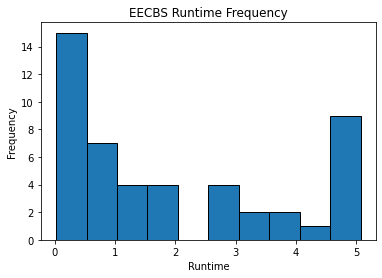

90 percentile cutoff: 5.00332


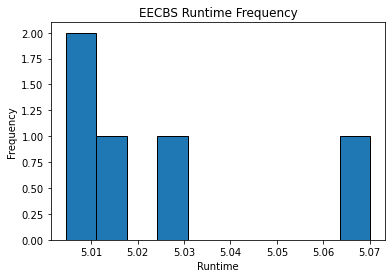

In [21]:
def plot(runtimes):
    plt.hist(runtimes, bins=10, edgecolor='black')  # 'bins' defines how many bins you want
    plt.title('EECBS Runtime Frequency')
    plt.xlabel('Runtime')
    plt.ylabel('Frequency')
    # print('Median:', np.median(all_runtimes))
    plt.show()

PERCENTILE = 90

all_runtimes = np.asarray(all_runtimes)
cutoff = np.percentile(all_runtimes, PERCENTILE)
cutoff_runtimes = all_runtimes[all_runtimes >= cutoff]

plot(all_runtimes)
print(f"{PERCENTILE} percentile cutoff:", cutoff)
plot(cutoff_runtimes)